<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>
<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Curso de Hidrología</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Probabilidad y estadística

## Objetivo

---



In [14]:
# Clonar el repositorio desde GitHub
!git clone -- https://github.com/paulmunozpauta/Hidrology_Course

Cloning into 'Hidrology_Course'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 94 (delta 22), reused 21 (delta 5), pack-reused 38 (from 1)
Receiving objects: 100% (94/94), 62.74 MiB | 23.96 MiB/s, done.
Resolving deltas: 100% (28/28), done.


Después de ejecutar la celda anterior, se crea una carpeta en nuestro entorno llamada:

**Hidrology_Course**

Esta carpeta contiene todos los archivos del curso.

Ahora debemos entrar a esa carpeta para trabajar con los datos.

# Entrar a la carpeta del repositorio
%cd Hidrology_Course
!ls




In [15]:
# Entrar a la carpeta del repositorio
%cd Hidrology_Course
!ls

/content/Hidrology_Course/Hidrology_Course
01_Delimitacion_cuenca.ipynb	   Data       Static
02_Probabilidad_estadística.ipynb  README.md



Instalación de librerías
En esta sección instalamos las librerías necesarias.

Librerías principales:
pandas
numpy
matplotlib

In [28]:


# Instalar librerías necesarias
!pip -q install pandas

In [29]:
#Importar librerías
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas

In [32]:
# ruta del archivo

archivo = "Data/Precipitación/PuertoMontt_DGA_10425001.xlsx"

# leer el archivo Excel
df = pd.read_excel(archivo)



In [47]:
# limpiar nombres de columnas
df.columns = df.columns.str.strip().str.lower()

# renombrar por seguridad si vienen con espacios o acentos raros
df = df.rename(columns={
    "agno": "anio",
    "año": "anio",
    "mes": "mes",
    "dia": "dia",
    "valor": "precipitacion_diaria_mm"
})

# convertir columnas a numéricas
for col in ["anio", "mes", "dia", "precipitacion_diaria_mm"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# eliminar filas con datos faltantes en columnas clave
df = df.dropna(subset=["anio", "mes", "dia", "precipitacion_diaria_mm"])

# convertir año, mes y día a enteros
df["anio"] = df["anio"].astype(int)
df["mes"] = df["mes"].astype(int)
df["dia"] = df["dia"].astype(int)

# crear columna fecha
df["fecha"] = pd.to_datetime(
    dict(year=df["anio"], month=df["mes"], day=df["dia"]),
    errors="coerce"
)

# eliminar fechas inválidas
df = df.dropna(subset=["fecha"])

# dejar solo la serie temporal final
ts = df[["fecha", "precipitacion_diaria_mm"]].copy()

# ordenar por fecha
ts = ts.sort_values("fecha").reset_index(drop=True)

# opcional: usar fecha como índice
ts = ts.set_index("fecha")

# mostrar resultado
print(ts.head())



            precipitacion_diaria_mm
fecha                              
1973-02-01                      0.0
1973-02-02                      0.0
1973-02-03                      0.0
1973-02-04                      0.0
1973-02-05                      0.0


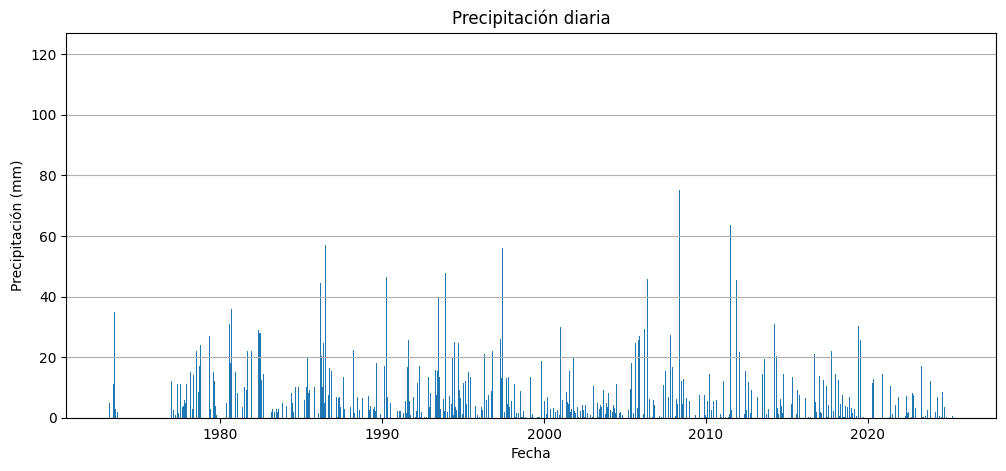

In [49]:


plt.figure(figsize=(12,5))

plt.bar(
    ts.index,  # ← aquí está la corrección
    ts["precipitacion_diaria_mm"],
    width=0.8  # ancho en días (mejor para datos diarios)
)

plt.title("Precipitación diaria")
plt.xlabel("Fecha")
plt.ylabel("Precipitación (mm)")
plt.grid(axis="y")

plt.show()

In [51]:


# asegurar frecuencia diaria
ts = ts.asfreq("D")

# conteo de días válidos por mes
dias_validos = ts["precipitacion_diaria_mm"].resample("ME").count()

# total de días por mes
dias_totales = ts["precipitacion_diaria_mm"].resample("ME").size()

# fracción faltante
fraccion_faltante = 1 - (dias_validos / dias_totales)

# suma mensual
suma_mensual = ts["precipitacion_diaria_mm"].resample("ME").sum()

# aplicar condición
ts_mensual = suma_mensual.where(fraccion_faltante <= 0.10)

# convertir a DataFrame
ts_mensual = ts_mensual.to_frame(name="precipitacion_mensual_mm")
# ordenar por fecha

# opcional: usar fecha como índice
ts_mensual.index = ts_mensual.index.to_period("M")


print(ts_mensual.head())

         precipitacion_mensual_mm
fecha                            
1973-02                     312.3
1973-03                      46.3
1973-04                      97.0
1973-05                     192.0
1973-06                     389.0


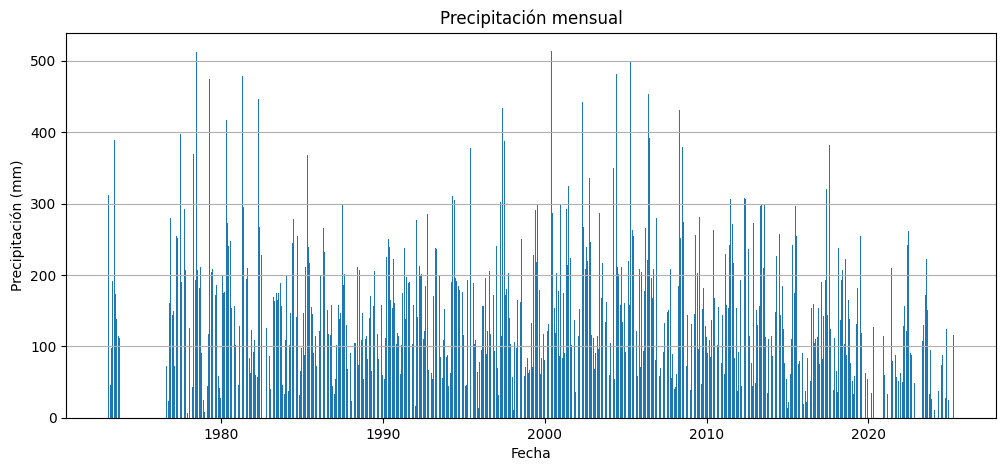

In [54]:

plt.figure(figsize=(12,5))

plt.bar(
    ts_mensual.index.to_timestamp(),   # convertir PeriodIndex a DatetimeIndex
    ts_mensual["precipitacion_mensual_mm"],
    width=20
)

plt.title("Precipitación mensual")
plt.xlabel("Fecha")
plt.ylabel("Precipitación (mm)")
plt.grid(axis="y")

plt.show()

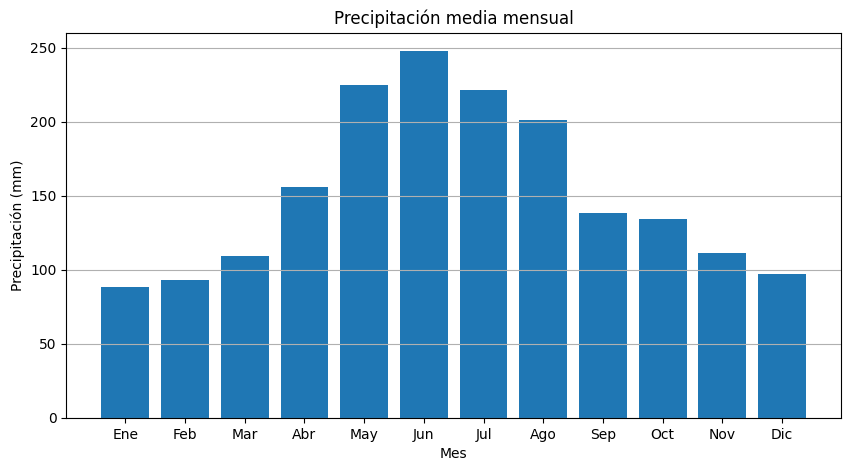

In [55]:

# promedio de todos los eneros, febreros, etc.
precipitacion_media_mensual = ts_mensual.groupby(ts_mensual.index.month).mean()

# nombres de meses
nombres_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                 "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

plt.figure(figsize=(10, 5))

plt.bar(
    precipitacion_media_mensual.index,
    precipitacion_media_mensual["precipitacion_mensual_mm"]
)

plt.title("Precipitación media mensual")
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.xticks(range(1, 13), nombres_meses)
plt.grid(axis="y")

plt.show()

estimar la probabilidad de que la precipitación media mensual de enero  en un año cualquiera sea: precipitacion< 35 mm precipitacion > 100 mm precipitacion, entre 35 y 100

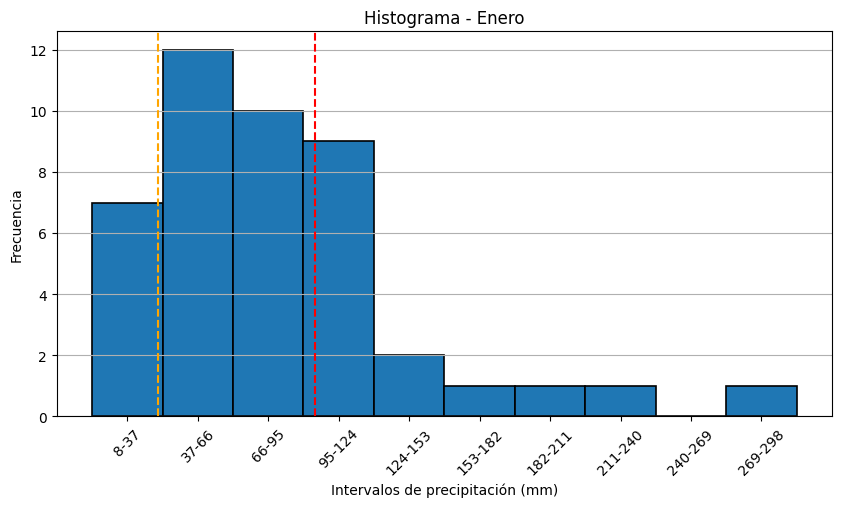

In [83]:



# extraer enero
enero = ts_mensual[ts_mensual.index.month == 1]['precipitacion_mensual_mm'].dropna()

.pyplot as plt

plt.figure(figsize=(10,5))

# calcular histograma y capturar bins
conteo, bins, _ = plt.hist(
    enero,
    bins=10,
    edgecolor='black',
    linewidth=1.2
)

# crear etiquetas tipo intervalo
labels = [f"{bins[i]:.0f}-{bins[i+1]:.0f}" for i in range(len(bins)-1)]

# centros de bins
centros = (bins[:-1] + bins[1:]) / 2

# poner etiquetas en eje X
plt.xticks(centros, labels, rotation=45)

# líneas de referencia
plt.axvline(35, linestyle='--', color="orange")
plt.axvline(100, linestyle='--', color="red")

plt.title("Histograma - Enero")
plt.xlabel("Intervalos de precipitación (mm)")
plt.ylabel("Frecuencia")

plt.grid(axis="y")

plt.show()

In [107]:

p_menor_35= (enero < 35).sum() / len(enero)
p_mayor_100 = (enero > 100).sum() / len(enero)
p_entre_35_100= ((enero >= 35) & (enero <= 100)).sum() /len(enero)
p_entre_35_100_2 = 1-p_menor_35-p_mayor_100
print("P(precipitacion < 35 mm)", p_menor_35)
print("P(precipitacion > 100 mm)", p_mayor_100)
print("P(35<=precipitacion <= 100 mm)", p_entre_35_100)
print("P(23500<=precipitacion <= 100 mm)", p_entre_35_100_2)

P(precipitacion < 35 mm) 0.13636363636363635
P(precipitacion > 100 mm) 0.3181818181818182
P(35<=precipitacion <= 100 mm) 0.5454545454545454
P(23500<=precipitacion <= 100 mm) 0.5454545454545454


Ahora para junio

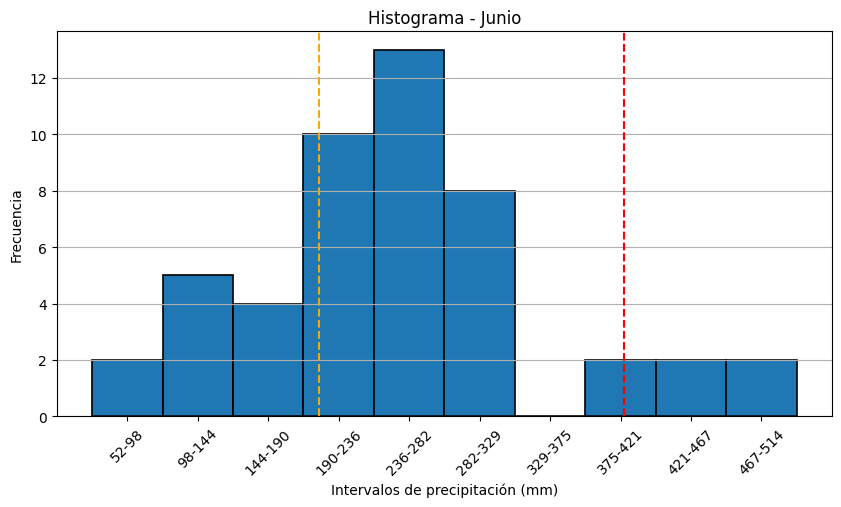

In [108]:

# extraer junio
junio = ts_mensual[ts_mensual.index.month == 6]['precipitacion_mensual_mm'].dropna()


plt.figure(figsize=(10,5))

# calcular histograma y capturar bins
conteo, bins, _ = plt.hist(
    junio,
    bins=10,
    edgecolor='black',
    linewidth=1.2
)

# crear etiquetas tipo intervalo
labels = [f"{bins[i]:.0f}-{bins[i+1]:.0f}" for i in range(len(bins)-1)]

# centros de bins
centros = (bins[:-1] + bins[1:]) / 2

# poner etiquetas en eje X
plt.xticks(centros, labels, rotation=45)

# líneas de referencia
plt.axvline(200, linestyle='--', color="orange")
plt.axvline(400, linestyle='--', color="red")

plt.title("Histograma - Junio")
plt.xlabel("Intervalos de precipitación (mm)")
plt.ylabel("Frecuencia")

plt.grid(axis="y")

plt.show()

In [109]:
p_menor_200 = (junio < 200).sum() / len(junio)
p_mayor_400 = (junio > 400).sum() / len(junio)
p_entre_200_400= ((junio >= 200) & (junio <= 400)).sum() /len(junio)
p_entre_200_400_2 = 1-p_menor_200-p_mayor_400
print("P(precipitacion < 200 mm)", p_menor_200)
print("P(precipitacion > 400 mm)", p_mayor_400)
print("P(200<=precipitacion <= 400 mm)", p_entre_200_400)
print("P(200<=precipitacion <= 400 mm)", p_entre_200_400_2)

P(precipitacion < 200 mm) 0.25
P(precipitacion > 400 mm) 0.08333333333333333
P(200<=precipitacion <= 400 mm) 0.6666666666666666
P(200<=precipitacion <= 400 mm) 0.6666666666666666


propbabilidad de tener 2 enero secos menores a 35mm

In [115]:
p_2eneros_consecutivos_menor35 = p_menor_35*p_menor_35
print(p_2eneros_consecutivos_menor35)

0.018595041322314047


preciptaion cmax diaria anual

In [56]:
# asegurar frecuencia diaria (opcional pero recomendable)
ts = ts.asfreq("D")

# calcular máximo diario por año
max_diaria_anual = ts["precipitacion_diaria_mm"].resample("YE").max()

# convertir a DataFrame
max_diaria_anual = max_diaria_anual.to_frame(name="precipitacion_max_diaria_anual_mm")

print(max_diaria_anual.head())

            precipitacion_max_diaria_anual_mm
fecha                                        
1973-12-31                               64.0
1974-12-31                                NaN
1975-12-31                                NaN
1976-12-31                               36.5
1977-12-31                               50.0


In [58]:
conteo_anual = ts["precipitacion_diaria_mm"].resample("YE").count()
print(conteo_anual)

fecha
1973-12-31    270
1974-12-31      0
1975-12-31      0
1976-12-31    122
1977-12-31    365
1978-12-31    334
1979-12-31    365
1980-12-31    366
1981-12-31    365
1982-12-31    303
1983-12-31    365
1984-12-31    366
1985-12-31    365
1986-12-31    365
1987-12-31    365
1988-12-31    366
1989-12-31    365
1990-12-31    365
1991-12-31    365
1992-12-31    366
1993-12-31    365
1994-12-31    365
1995-12-31    334
1996-12-31    366
1997-12-31    365
1998-12-31    365
1999-12-31    365
2000-12-31    366
2001-12-31    365
2002-12-31    365
2003-12-31    365
2004-12-31    366
2005-12-31    365
2006-12-31    365
2007-12-31    365
2008-12-31    366
2009-12-31    365
2010-12-31    365
2011-12-31    365
2012-12-31    366
2013-12-31    365
2014-12-31    365
2015-12-31    365
2016-12-31    366
2017-12-31    365
2018-12-31    365
2019-12-31    360
2020-12-31    169
2021-12-31    341
2022-12-31    353
2023-12-31    266
2024-12-31    338
2025-12-31     47
Freq: YE-DEC, Name: precipitacion_diaria

In [62]:
# asegurar frecuencia diaria (opcional)
ts = ts.asfreq("D")

col = "precipitacion_diaria_mm"

# días válidos por año
dias_validos = ts[col].resample("YE").count()

# total de días por año
dias_totales = ts[col].resample("YE").size()

# fracción faltante
fraccion_faltante = 1 - (dias_validos / dias_totales)

# máximo anual
max_anual = ts[col].resample("YE").max()

# aplicar filtro (≤10% faltantes)
max_anual = max_anual.where(fraccion_faltante <= 0.10)

# convertir a DataFrame
max_anual = max_anual.to_frame(name="precipitacion_max_diaria_anual_mm")

print(max_anual)

            precipitacion_max_diaria_anual_mm
fecha                                        
1973-12-31                                NaN
1974-12-31                                NaN
1975-12-31                                NaN
1976-12-31                                NaN
1977-12-31                               50.0
1978-12-31                               49.0
1979-12-31                               49.5
1980-12-31                               50.0
1981-12-31                               89.0
1982-12-31                                NaN
1983-12-31                               42.0
1984-12-31                               49.0
1985-12-31                               50.0
1986-12-31                               57.0
1987-12-31                               51.5
1988-12-31                               49.3
1989-12-31                               49.8
1990-12-31                               57.3
1991-12-31                               48.5
1992-12-31                        

In [60]:
print(fraccion_faltante[fraccion_faltante > 0.10])

fecha
1973-12-31    0.191617
1974-12-31    1.000000
1975-12-31    1.000000
1976-12-31    0.666667
1982-12-31    0.169863
2020-12-31    0.538251
2023-12-31    0.271233
2025-12-31    0.594828
Name: precipitacion_diaria_mm, dtype: float64


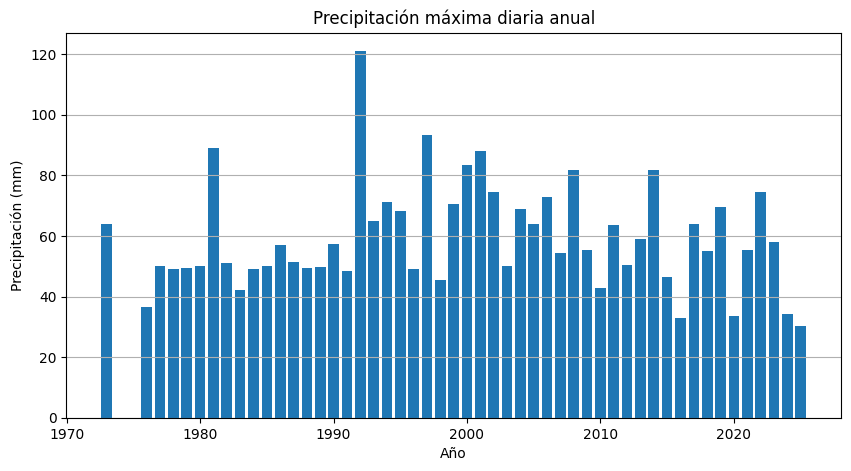

In [61]:
plt.figure(figsize=(10,5))

plt.bar(
    max_diaria_anual.index.year,
    max_diaria_anual["precipitacion_max_diaria_anual_mm"]
)

plt.title("Precipitación máxima diaria anual")
plt.xlabel("Año")
plt.ylabel("Precipitación (mm)")
plt.grid(axis="y")

plt.show()